In [1]:
import geopandas as gpd
import shapely
import pandas as pd
import osmnx as ox
from sklearn.preprocessing import MinMaxScaler
import session_info
import overpy
import matplotlib.pyplot as plt
import os
import contextily as ctx
from collections import Counter
import re

In [2]:
def get_place_profile(place):
    
    folderout = 'data/' + place
    if not os.path.exists(folderout):
        os.makedirs(folderout)
        
    roads = ox.graph_from_place(place, network_type='all')
    public_transport = ox.features_from_place(place, tags={'public_transport':True}) 
    ox.save_graphml(roads, filepath = folderout + '/roads.graphml')
    public_transport.to_file(folderout + '/public_transport.geojson', driver='GeoJSON')
    
    parks = ox.features_from_place(place, tags={'leisure':'park'})
    recreation = ox.features_from_place(place, tags={'leisure':['recreation_ground', 'pitch']})  
    parks.to_file(folderout + '/parks.geojson', driver='GeoJSON')
    recreation.to_file(folderout + '/recreation.geojson', driver='GeoJSON')
    
    healthcare = ox.features_from_place(place, tags={'amenity':['hospital', 'pharmacy']})
    education = ox.features_from_place(place, tags={'amenity':['school', 'university']})    
    healthcare.to_file(folderout + '/healthcare.geojson', driver='GeoJSON')
    education.to_file(folderout + '/education.geojson', driver='GeoJSON')
    
    emergency_services = ox.features_from_place(place, tags={'amenity':['police', 'fire_station', 'clinic']})
    street_light = ox.features_from_place(place, tags={'highway':['street_lamp']})
    emergency_services.to_file(folderout + '/emergency_services.geojson', driver='GeoJSON')
    street_light.to_file(folderout + '/street_light.geojson', driver='GeoJSON')
    
    commerce = ox.features_from_place(place, tags={'shop': True})
    employment_centers = ox.features_from_place(place, tags={'office': True, 'industrial': True})
    commerce.to_file(folderout + '/commerce.geojson', driver='GeoJSON')
    employment_centers.to_file(folderout + '/employment_centers.geojson', driver='GeoJSON')

In [3]:
district_numbers = [f"{i}{'er' if i < 2 else 'e'}" for i in range(1, 17)]

for dn in district_numbers:
    place = dn + ' arrondissement, Marseille'
    admin_d = ox.geocode_to_gdf(place)
    get_place_profile(place)
    admin_d.to_file('data/' + place + '/admin_boundaries.geojson', driver='GeoJSON')

In [4]:
def characterize_district(place) :
    folderin = 'data/' + place
    
    roads_graph = ox.load_graphml(folderin + '/roads.graphml')
    parks = gpd.read_file(folderin + '/parks.geojson')
    recreation = gpd.read_file(folderin + '/recreation.geojson')
    public_transport = gpd.read_file(folderin + '/public_transport.geojson')
    healthcare = gpd.read_file(folderin + '/healthcare.geojson')
    education = gpd.read_file(folderin + '/education.geojson')
    emergency_services = gpd.read_file(folderin + '/emergency_services.geojson')
    street_lighting = gpd.read_file(folderin + '/street_light.geojson')
    commerce = gpd.read_file(folderin + '/commerce.geojson')
    employment_centers = gpd.read_file(folderin + '/employment_centers.geojson')
    
    
    crs = 23700
    edges = ox.graph_to_gdfs(roads_graph, nodes=False, edges=True)
    road_length = edges['length'].sum() / 1000
    total_area = edges.to_crs(crs).union_all().convex_hull.area/1000**2
    road_density = road_length/total_area
    public_transport_density = len(public_transport) / total_area
    
    park_coverage = (parks.to_crs(crs).area.sum()) / 1000**2 / total_area
    recreation_density = len(recreation) / total_area
    
    healthcare_accesibility = len(healthcare) / total_area
    education_accessibility = len(education) / total_area
    
    emergency_services_density = len(emergency_services) / total_area
    street_lighting_density = len(street_lighting) / total_area
    
    commerce_density = len(commerce) / total_area
    employment_centers_density = len(employment_centers) / total_area

    data = {
        'place' : place,
        'Road Density' : road_density,
        'Public Transport Density' : public_transport_density,
        'Park Coverage' : park_coverage,
        'Recreation Density' : recreation_density,
        'Healthcare Accesibility' : healthcare_accesibility,
        'Education Accessibility' : education_accessibility,
        'Emergency Services Density' : emergency_services_density,
        'Street Lighting Density' : street_lighting_density,
        'Commerce Density' : commerce_density,
        'Employment Centers Density' : employment_centers_density
    }
    
    df = pd.DataFrame([data]) 
    
    return df

In [18]:
districts = [f for f in os.listdir('data') if '.' not in f]

df_all = []

for district in districts :
    df = characterize_district(district)
    print(district, len(df))
    df_all.append(df)

df_all = pd.concat(df_all).set_index('place')

10e arrondissement, Marseille 1
11e arrondissement, Marseille 1
12e arrondissement, Marseille 1
13e arrondissement, Marseille 1
14e arrondissement, Marseille 1
15e arrondissement, Marseille 1
16e arrondissement, Marseille 1
1er arrondissement, Marseille 1
2e arrondissement, Marseille 1
3e arrondissement, Marseille 1
4e arrondissement, Marseille 1
5e arrondissement, Marseille 1
6e arrondissement, Marseille 1
7e arrondissement, Marseille 1
8e arrondissement, Marseille 1
9e arrondissement, Marseille 1


In [19]:
df_all.corr()

,Road Density,Public Transport Density,Park Coverage,Recreation Density,Healthcare Accesibility,Education Accessibility,Emergency Services Density,Street Lighting Density,Commerce Density,Employment Centers Density
Road Density,1.000000,0.808383,-0.145886,0.330803,0.818261,0.823557,0.747894,0.220462,0.689041,0.684638
Public Transport Density,0.808383,1.000000,-0.113127,0.326602,0.957415,0.805846,0.907877,0.124118,0.871588,0.841751
Park Coverage,-0.145886,-0.113127,1.000000,0.391953,-0.148315,0.001992,-0.011999,0.235084,-0.200424,-0.171007
Recreation Density,0.330803,0.326602,0.391953,1.000000,0.139016,0.302222,0.516977,0.500813,-0.027238,-0.012485
Healthcare Accesibility,0.818261,0.957415,-0.148315,0.139016,1.000000,0.810240,0.807643,-0.028838,0.960355,0.933868
Education Accessibility,0.823557,0.805846,0.001992,0.302222,0.810240,1.000000,0.818100,0.148703,0.678433,0.766060
Emergency Services Density,0.747894,0.907877,-0.011999,0.516977,0.807643,0.818100,1.000000,0.198520,0.655109,0.680902
Street Lighting Density,0.220462,0.124118,0.235084,0.500813,-0.028838,0.148703,0.198520,1.000000,-0.152041,-0.157950
Commerce Density,0.689041,0.871588,-0.200424,-0.027238,0.960355,0.678433,0.655109,-0.152041,1.000000,0.968853
Employment Centers Density,0.684638,0.841751,-0.171007,-0.012485,0.933868,0.766060,0.680902,-0.157950,0.968853,1.000000


In [20]:
df = df_all.copy()

In [21]:
gdf_admin = []

for district in os.listdir('data'):
    if '.DS' not in district:
        gdf = gpd.read_file('data/' + district + '/admin_boundaries.geojson')
        gdf['place'] = district
        gdf_admin.append(gdf)

gdf_admin = pd.concat(gdf_admin)

In [22]:
scaler = MinMaxScaler(feature_range=(1,10))

df_normalized = pd.DataFrame(
    scaler.fit_transform(df),
    columns = df.columns,
    index = df.index
)

df_normalized.head()

,Road Density,Public Transport Density,Park Coverage,Recreation Density,Healthcare Accesibility,Education Accessibility,Emergency Services Density,Street Lighting Density,Commerce Density,Employment Centers Density
place,,,,,,,,,,
"10e arrondissement, Marseille",6.069079,2.459337,3.327570,5.872202,1.847432,2.441215,1.537727,4.409057,1.450225,1.423265
"11e arrondissement, Marseille",1.583980,1.337769,1.593209,1.700237,1.080665,1.185059,1.069918,2.643480,1.086582,1.000000
"12e arrondissement, Marseille",3.837563,2.890859,2.554267,5.967583,1.866219,2.277476,2.836579,7.791136,1.252367,1.145581
"13e arrondissement, Marseille",2.948544,1.989057,2.696973,3.371362,1.387275,1.999618,1.686431,3.388591,1.022123,1.041542
"14e arrondissement, Marseille",3.692546,2.428264,2.996126,4.443393,1.521284,2.225410,1.862385,3.814385,1.101427,1.141722


In [23]:
weights = {
    'Road Density': 0.1,
    'Public Transport Density': 0.15,
    'Park Coverage': 0.1,
    'Recreation Density': 0.1,
    'Healthcare Accesibility': 0.1,
    'Education Accessibility': 0.1,
    'Emergency Services Density': 0.1,
    'Street Lighting Density': 0.1,
    'Commerce Density': 0.15,
    'Employment Centers Density': 0.1
}

In [24]:
for feature in df_normalized.columns:
    df_normalized[feature] = df_normalized[feature] * weights[feature]

In [25]:
df_normalized['Unified Index'] = df_normalized.sum(axis=1)

df_normalized[['Unified Index']]

,Unified Index
place,
"10e arrondissement, Marseille",3.279189
"11e arrondissement, Marseille",1.549307
"12e arrondissement, Marseille",3.449124
"13e arrondissement, Marseille",2.303711
"14e arrondissement, Marseille",2.699179
"15e arrondissement, Marseille",3.290863
"16e arrondissement, Marseille",1.874203
"1er arrondissement, Marseille",7.836641
"2e arrondissement, Marseille",2.287843


In [26]:
scaler = MinMaxScaler(feature_range=(1,10))

df_normalized['Unified Index'] = scaler.fit_transform(df_normalized[['Unified Index']])

df_normalized['Unified Index'] = df_normalized['Unified Index'].round(0)

In [27]:
gdf_index = gdf_admin[['place', 'geometry']].merge(df_normalized[['Unified Index']], left_on='place', right_index=True)

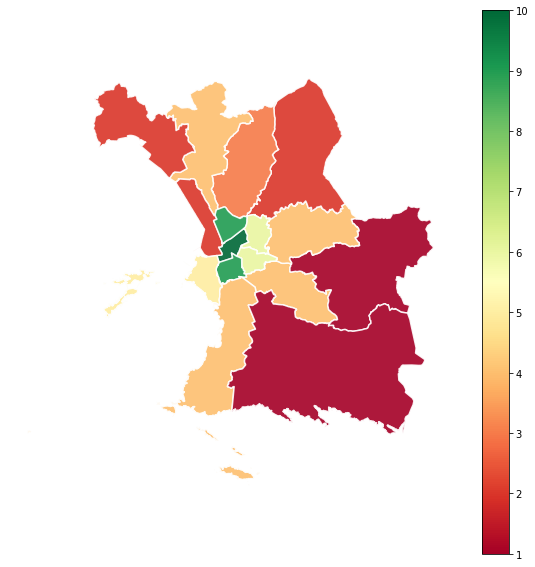

In [28]:
f, ax = plt.subplots(1,1, figsize=(10,10))

gdf_index.plot(ax=ax, edgecolor='w', linewidth=1.5, alpha=0.9, column='Unified Index', cmap='RdYlGn', legend=True)

ax.axis('off');

In [29]:
admin_poly = admin_d.geometry.to_list()[0]

footprints = ox.features_from_polygon(admin_poly, tags={'building':True})

Counter(footprints.dropna(subset=['amenity'])['amenity'].to_list()).most_common()

[('community_centre', 5),
 ('shelter', 5),
 ('parking', 4),
 ('fast_food', 4),
 ('place_of_worship', 4),
 ('restaurant', 3),
 ('arts_centre', 3),
 ('social_facility', 2),
 ('social_centre', 1),
 ('kindergarten', 1),
 ('childcare', 1),
 ('ferry_terminal', 1),
 ('cafe', 1),
 ('events_venue', 1),
 ('cinema', 1),
 ('bar', 1),
 ('bicycle_parking', 1)]

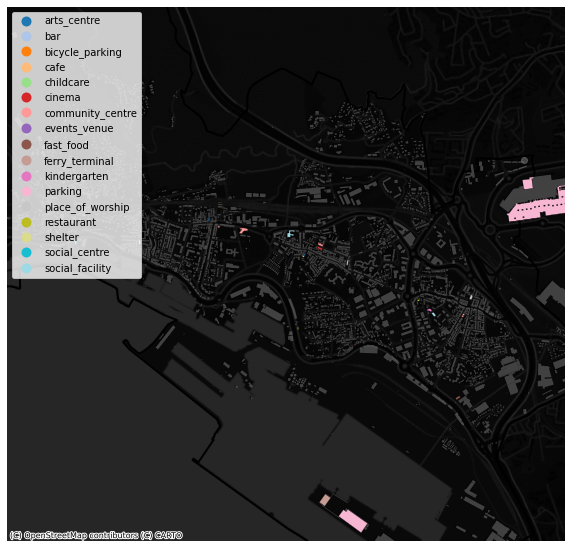

In [43]:
crs_local = 2154

f, ax = plt.subplots(1,1, figsize=(10,10))

admin_d.to_crs(crs_local).plot(ax=ax, color='none', edgecolor='k', linewidth=2)

footprints.to_crs(crs_local).plot(ax=ax, color='grey', alpha=0.5)
footprints.to_crs(crs_local).plot(ax=ax, column='amenity', edgecolor='k', linewidth=0.3, cmap='tab20', legend=True)

    
ctx.add_basemap(ax, crs = crs_local, source = ctx.providers.CartoDB.DarkMatterNoLabels)

ax.set_ylim([6252000, 6255800.08])
ax.set_xlim([886727, 890700])

ax.axis('off');